In [1]:
from metrics          import eval_model, compare_metric
from torch.utils.data import DataLoader, TensorDataset
from model            import GenerateModel
from training         import train_model
from gensim.models    import Word2Vec
from tqdm             import tqdm

import numpy             as np
import matplotlib.pyplot as plt
import torch
import os

# device     = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu'); print(f'Deivce: {device}')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'); print(f'Deivce: {device}')
model_path = os.path.join(os.getcwd(),'Model','model.tar')

Deivce: cuda


In [2]:
X_train = np.load('X_train.npy')
X_test  = np.load('X_test.npy')

Y_train = np.load('Y_train.npy')
Y_test  = np.load('Y_test.npy')

X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)
X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32) 

train_loader = DataLoader(TensorDataset(X_train,Y_train), batch_size = 16,shuffle=False, pin_memory = True)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test) , batch_size = 64,shuffle=False, pin_memory = True)

In [3]:
model = GenerateModel(); model.to(device)
model.load_state_dict(torch.load(os.path.join(os.getcwd(),'Model','model.tar'),weights_only=True,map_location=device))

<All keys matched successfully>

In [4]:
epochs = 4000

In [5]:
model.to(device=device)
loss_module = torch.nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr = 0.0001, betas =  (0.9,0.99))

intermediate_hist = []
for epoch in tqdm(range(epochs)):
    hist, best_model, best_loss = train_model(model = model,
                        device      = device,
                        optimizer   = optimizer,
                        data_loader = train_loader,
                        loss_module = loss_module,
                        num_epochs  = 1)
    if epoch % 1 == 0:
        h = eval_model(model = model,device = device,label_space = 50,data_loader  = test_loader)
        intermediate_hist.append(h)

100%|██████████| 4000/4000 [1:52:37<00:00,  1.69s/it]


In [6]:
torch.save(model.state_dict(),f = os.path.join(os.getcwd(),'Model','model2.tar'))

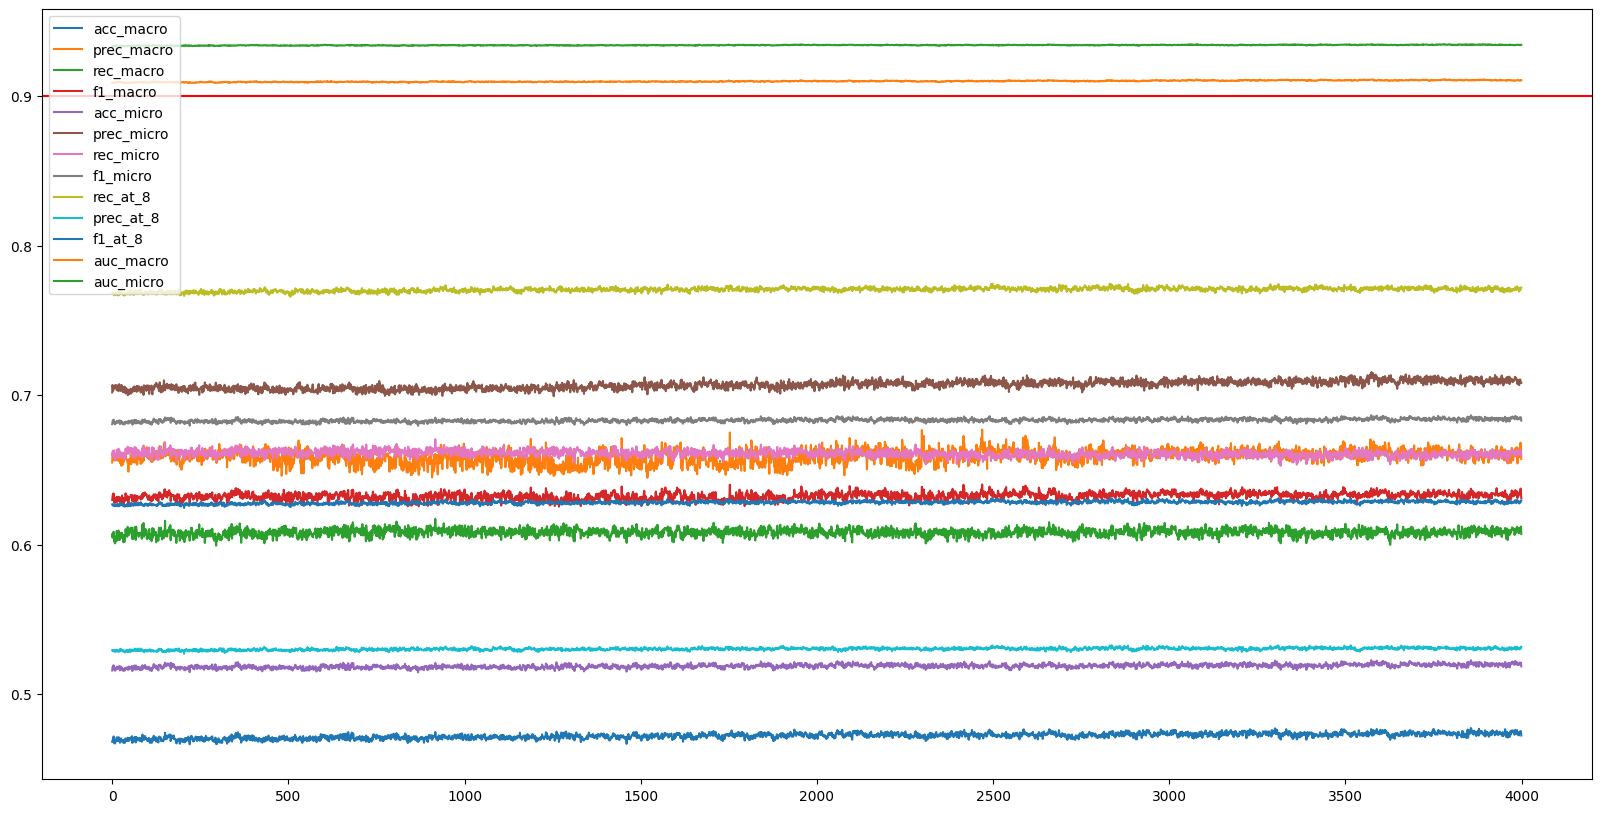

In [15]:
# Visualize the eval over the different training size
plt.figure(figsize=(20,10))
# plt.tick_params(
#     axis   ='x',          
#     which  ='both',      
#     bottom = False,      
#     top    = False,
#     labelbottom = False)

for key in intermediate_hist[0].keys():
    # plt.plot([_ for _ in range(epochs//1)],[m[key] for m in intermediate_hist], label = key)
    plt.plot([m[key] for m in intermediate_hist], label = key)
plt.legend()
plt.axhline(y=0.9, color='r', linestyle='-')
plt.savefig('training3.png')

In [19]:
intermediate_hist[0]['auc_micro'],intermediate_hist[-1]['auc_micro']

(0.9331890150045156, 0.9342419886411647)

---

In [8]:
benchmark = {
    'auc_macro' : 0.884,
    'auc_micro' : 0.916,
    'f1_macro'  : 0.576,
    'f1_micro'  : 0.633
}

In [9]:
model.load_state_dict(torch.load(os.path.join(os.getcwd(),'Model','model2.tar'),weights_only=True,map_location=device))

<All keys matched successfully>

In [10]:
results = eval_model(
           model  = model,
           device = device,
           data_loader = test_loader,
           label_space = 50)

In [11]:
for k,v in benchmark.items():
    if k in results:
        print(compare_metric(benchmark,results,k))

auc_macro: 3.02% change (0.8840 → 0.9107)
auc_micro: 1.99% change (0.9160 → 0.9342)
f1_macro: 9.57% change (0.5760 → 0.6311)
f1_micro: 7.88% change (0.6330 → 0.6829)


- auc_macro: 2.90% change (0.8840 → 0.9096)
- auc_micro: 1.95% change (0.9160 → 0.9339)
- f1_macro: 9.80% change (0.5760 → 0.6325)
- f1_micro: 7.74% change (0.6330 → 0.6820)

In [12]:
model.load_state_dict(torch.load(os.path.join(os.getcwd(),'Model','federated_model3.tar'),weights_only=True,map_location=device))

<All keys matched successfully>

In [13]:
federated_results = eval_model(
           model  = model,
           device = device,
           data_loader = test_loader,
           label_space = 50)

In [16]:
for k,v in federated_results.items():
    if k in results:
        print(compare_metric(results,federated_results,k))

acc_macro: -2.99% change (0.4723 → 0.4582)
prec_macro: -21.94% change (0.6572 → 0.5130)
rec_macro: 29.13% change (0.6070 → 0.7838)
f1_macro: -1.74% change (0.6311 → 0.6202)
acc_micro: -7.49% change (0.5185 → 0.4796)
prec_micro: -23.92% change (0.7081 → 0.5387)
rec_micro: 23.42% change (0.6593 → 0.8138)
f1_micro: -5.06% change (0.6829 → 0.6483)
rec_at_8: -1.42% change (0.7719 → 0.7610)
prec_at_8: -1.22% change (0.5314 → 0.5249)
f1_at_8: -1.30% change (0.6295 → 0.6213)
auc_macro: -0.32% change (0.9107 → 0.9077)
auc_micro: -0.21% change (0.9342 → 0.9323)
